# [3주차] Transformer 과제

- **과제 목적:** 이번 과제는 하나의 흐름 안에서 Transformer의 핵심 연산을 직접 구현하고, 마스킹 전후를 비교한 뒤, BERT와 GPT의 예측 방식을 관찰하는 과제로 출제해봤습니다. 완성된 코드를 실행하는 것에서 끝내지 않고, 실제로 실행하며 얻은 수치와 출력 결과를 근거로 각 개념을 해석하면서 트랜스포머를 이해해주시면 됩니다!

## 전체 흐름

> Scaled Dot-Product Attention 구현 → Causal Mask 적용 → BERT와 GPT 결과 비교 → 전체 해석

### 제출 시 유의사항
- 코드 셀의 `TODO`와 주석의 빈칸을 모두 채워주세요.
- 서술형 답변은 **본인이 실행해 얻은 값이나 출력**을 반드시 이용해서 작성해주세요.
- 마지막 셀의 생성형 AI 활용 내역을 반드시 작성해주세요.


## 0. 환경 설정

아래 셀을 실행하여 필요한 라이브러리를 설치하고 시드를 고정합니다.

In [1]:
!pip -q install transformers

import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Hugging Face의 다운로드 진행바/경고를 줄여 과제 출력이 너무 길어지지 않게 합니다.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForCausalLM,
)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


device: cuda


# 1. 필수 과제

## 1-1. Scaled Dot-Product Attention 직접 구현

다음 식을 코드로 구현합니다.

$$
\mathrm{Attention}(Q,K,V)
=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

아래 예제에서 각 행은 하나의 토큰을 나타냅니다. 코드의 빈칸과 주석을 채운 뒤, **Attention Score → Weight → Output**의 흐름을 확인해주세요.


In [2]:
# 세 토큰의 Q, K, V 예시
Q = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])

# 첫 번째 Query에서 최대 Attention이 하나만 나오도록 세 번째 Key를 [0.5, 0.5]로 둡니다.
K = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [0.5, 0.5],
])

V = torch.tensor([
    [10.0, 0.0],
    [0.0, 10.0],
    [5.0, 5.0],
])


def scaled_dot_product_attention(Q, K, V, mask=None):
    # [빈칸] d_k는 어떤 벡터의 차원을 뜻하는가?
    # 답: Key 벡터의 차원
    d_k = Q.size(-1)

    # TODO 1: Query와 모든 Key의 내적 계산
    scores = Q @ K.transpose(-2, -1)

    # TODO 2: 내적값을 sqrt(d_k)로 나누기
    scaled_scores = scores / math.sqrt(d_k)

    # Mask가 주어진 경우 미래 위치의 score를 -inf로 바꿉니다.
    if mask is not None:
        scaled_scores = scaled_scores.masked_fill(mask, float('-inf'))

    # TODO 3: 마지막 차원에 Softmax를 적용해 Attention Weight 구하기
    weights = torch.softmax(scaled_scores, dim=-1)

    # TODO 4: Attention Weight와 Value의 가중합 계산
    output = weights @ V

    return scores, scaled_scores, weights, output

scores, scaled_scores, weights, output = scaled_dot_product_attention(Q, K, V)

print("[Raw Attention Scores]\n", scores)
print("\n[Scaled Scores]\n", scaled_scores)
print("\n[Attention Weights]\n", weights)
print("\n[Attention Output]\n", output)


[Raw Attention Scores]
 tensor([[1.0000, 0.0000, 0.5000],
        [0.0000, 1.0000, 0.5000],
        [1.0000, 1.0000, 1.0000]])

[Scaled Scores]
 tensor([[0.7071, 0.0000, 0.3536],
        [0.0000, 0.7071, 0.3536],
        [0.7071, 0.7071, 0.7071]])

[Attention Weights]
 tensor([[0.4555, 0.2246, 0.3199],
        [0.2246, 0.4555, 0.3199],
        [0.3333, 0.3333, 0.3333]])

[Attention Output]
 tensor([[6.1546, 3.8454],
        [3.8454, 6.1546],
        [5.0000, 5.0000]])


In [3]:
# 과정 확인 장치: 각 Query의 Attention Weight 합은 1이어야 합니다.
row_sums = weights.sum(dim=-1)
print("각 행의 합:", row_sums)

# TODO 5: row_sums가 모두 1에 가까운지 검증
assert torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-5)

# 첫 번째 Query가 가장 크게 참고한 Key의 인덱스
most_attended_key = weights[0].argmax().item()
print("첫 번째 Query가 가장 크게 참고한 Key index:", most_attended_key)


각 행의 합: tensor([1., 1., 1.])
첫 번째 Query가 가장 크게 참고한 Key index: 0


### 1-1 결과 해석

1. 첫 번째 Query가 가장 크게 참고한 Key의 인덱스와 가중치는 얼마인가요?
   - **답:** 첫 번째 Query가 가장 크게 참고한 Key의 인덱스는 0이고, 가중치는 0.4555이다.
2. 그 Key의 가중치가 가장 큰 이유를 Q와 K의 내적 관점에서 설명해주세요.
   - **답:** Q[0]=[1,0]과 K[0]=[1,0]의 내적은 1으로 세 Key중 가장 크고 내적이 클수록 두 벡터의 방향이 비슷하다는 뜻이므로 softmax를 거치며 가장 큰 가중치를 받게 된다.
3. Attention Output은 Value 하나를 그대로 선택한 결과인가요, 여러 Value를 결합한 결과인가요?
   - **답:** Attention Output은 여러 Value를 결합한 결과이다.
4. `sqrt(d_k)`로 나누는 Scaling이 필요한 이유를 Softmax와 연결해 설명해주세요.
   - **답:** 벡터의 차원이 커질수록 값이 분산이 커져 Softmax의 기울기 소실 문제가 발생할 수 있다. 이를 방지하기 위해 `sqrt(d_k)`로 나누는 Scaling이 필요하다.


## 1-2. Look-ahead Mask 적용하기

같은 Q, K, V에 **Causal Mask(Look-ahead Mask)** 를 적용해 미래 토큰을 보지 못하게 합니다. 마스크 자체와 Masked Self-Attention은 같은 말이 아닙니다.

- **Look-ahead Mask:** 미래 위치를 가리는 마스크
- **Masked Self-Attention:** Self-Attention에 Look-ahead Mask를 적용한 연산

In [4]:
seq_len = Q.size(0)

# TODO 1: 주대각선 위쪽을 True로 갖는 마스크 만들기
# 힌트: torch.triu(..., diagonal=1)
causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)

_, _, unmasked_weights, _ = scaled_dot_product_attention(Q, K, V)
_, _, masked_weights, masked_output = scaled_dot_product_attention(
    Q, K, V, mask=causal_mask
)

print("[Causal Mask]\n", causal_mask)
print("\n[Mask 적용 전 Weight]\n", unmasked_weights)
print("\n[Mask 적용 후 Weight]\n", masked_weights)
print("\n[Masked Attention Output]\n", masked_output)


[Causal Mask]
 tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

[Mask 적용 전 Weight]
 tensor([[0.4555, 0.2246, 0.3199],
        [0.2246, 0.4555, 0.3199],
        [0.3333, 0.3333, 0.3333]])

[Mask 적용 후 Weight]
 tensor([[1.0000, 0.0000, 0.0000],
        [0.3302, 0.6698, 0.0000],
        [0.3333, 0.3333, 0.3333]])

[Masked Attention Output]
 tensor([[10.0000,  0.0000],
        [ 3.3024,  6.6976],
        [ 5.0000,  5.0000]])


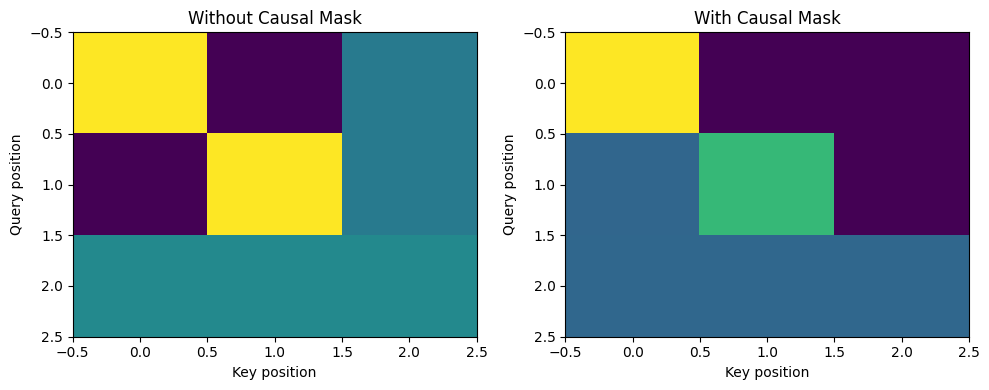

In [5]:
# Attention Weight 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(unmasked_weights.detach().numpy(), aspect="auto")
axes[0].set_title("Without Causal Mask")
axes[0].set_xlabel("Key position")
axes[0].set_ylabel("Query position")

axes[1].imshow(masked_weights.detach().numpy(), aspect="auto")
axes[1].set_title("With Causal Mask")
axes[1].set_xlabel("Key position")
axes[1].set_ylabel("Query position")

plt.tight_layout()
plt.show()

### 1-2 결과 해석

1. Query index 0은 마스크 적용 후 어느 Key까지 참고할 수 있나요?
   - **답:** Key index 0 까지만 참고할 수 있다.
2. 마스크 적용 후 Weight 행렬이 삼각형 모양이 되는 이유를 설명해주세요.
   - **답:** Causal mask를 통해 각 Query 위치는 자신보다 미래위치의 Key를 참고하지 못하도록 차단된다. 그 결과 행렬의 우상단은 가중치가 0이되고 대각선을 포함한 좌하단에만 유효한 가중치가 남기 때문에 행렬이 삼각형 모양이 된다.
3. Look-ahead Mask를 적용한 위치의 Weight가 0이 되는 과정을 `-∞ → Softmax`와 연결해 서술해주세요.
   - **답:** Look-ahead Mask는 미래 단어 위치의 어텐션 점수를 -∞로 대체한 뒤 Softmax 함수를 적용해 최종 Weight를 0으로 만든다. Softmax 계산 과정에서 지수함수에 -∞가 입력되면 수학적으로 0이 되므로 분자가 0이 된 미래 위치의 Weight는 0이 된다.
4. Padding Mask와 Look-ahead Mask의 목적의 차이를 한 문장씩 간단하게 작성해주세요.
   - **Padding Mask:** 문장의 길이를 맞추기 위해 억지로 채운 무의미한 패딩 토큰을 어텐션 연산에서 제외
   - **Look-ahead Mask:** 디코더가 문장을 생성할 때 아직 나오지 않은 미래의 단어를 미리 보지 못하게 차단


## 1-3. BERT와 GPT의 예측 방식 비교

이제 사전학습 모델을 사용해 두 모델의 차이를 관찰합니다.

- **BERT:** Encoder 기반, 양방향 문맥, Masked Language Model
- **GPT:** Decoder 기반, Causal Mask, 이전 토큰만 이용하는 Autoregressive Language Model

두 모델은 목적이 다르므로 정확도 경쟁이 아니라, **입력과 예측 방식의 차이**를 해석하는 것이 핵심입니다.

In [6]:
# 모델 불러오기
bert_name = "bert-base-uncased"
gpt_name = "gpt2"

# TODO 1: BERT tokenizer와 Masked LM model 불러오기
bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModelForMaskedLM.from_pretrained(bert_name).to(DEVICE)
_ = bert_model.eval()

# TODO 2: GPT tokenizer와 Causal LM model 불러오기
gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_name)
gpt_model = AutoModelForCausalLM.from_pretrained(gpt_name).to(DEVICE)
_ = gpt_model.eval()

print("BERT / GPT 모델 로드 완료")


BERT / GPT 모델 로드 완료


In [7]:
# ----- BERT: [MASK]의 앞뒤 문맥을 모두 이용한 단어 예측 -----
# [MASK] 뒤의 "to withdraw money"까지 활용할 수 있다는 점이 핵심
bert_sentence = "I went to the [MASK] to withdraw money."
bert_inputs = bert_tokenizer(bert_sentence, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    bert_logits = bert_model(**bert_inputs).logits

mask_positions = (bert_inputs["input_ids"] == bert_tokenizer.mask_token_id).nonzero(as_tuple=False)
assert len(mask_positions) == 1, "[MASK] 토큰은 정확히 하나만 있어야 합니다."
mask_index = mask_positions[0, 1].item()
mask_logits = bert_logits[0, mask_index, :]

# TODO 3: logit이 높은 상위 5개 토큰의 id 구하기
bert_top_ids = torch.topk(mask_logits, 5).indices
bert_top_tokens = [bert_tokenizer.decode([idx]).strip() for idx in bert_top_ids]
print("문장:", bert_sentence)
print("BERT top-5 predictions:", bert_top_tokens)


문장: I went to the [MASK] to withdraw money.
BERT top-5 predictions: ['bank', 'banks', 'store', 'atm', 'office']


In [8]:
# ----- GPT: 지금까지의 토큰만 이용한 다음 토큰 예측 -----
# GPT는 뒤 문맥을 볼 수 없으므로, 현재까지 주어진 prefix에서 다음 토큰을 예측
gpt_prompt = "I went to the bank to withdraw"
gpt_inputs = gpt_tokenizer(gpt_prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    gpt_logits = gpt_model(**gpt_inputs).logits

next_token_logits = gpt_logits[0, -1, :]

# TODO 4: 다음 토큰 후보 상위 5개의 id 구하기
gpt_top_ids = torch.topk(next_token_logits, 5).indices
gpt_top_tokens = [gpt_tokenizer.decode([idx]) for idx in gpt_top_ids]
print("Prompt:", gpt_prompt)
print("GPT next-token top-5:", gpt_top_tokens)


Prompt: I went to the bank to withdraw
GPT next-token top-5: [' money', ' my', ' the', ' $', ' some']


In [9]:
# GPT의 Autoregressive 생성 과정 관찰
prompt = "In natural language processing, Transformer models can"
inputs = gpt_tokenizer(prompt, return_tensors="pt").to(DEVICE)

# TODO 5: max_new_tokens=20, do_sample=False 조건으로 문장 생성
generated_ids = gpt_model.generate(
    **inputs,
    max_new_tokens=20,
    do_sample=False,
    pad_token_id=gpt_tokenizer.eos_token_id,
)

print(gpt_tokenizer.decode(generated_ids[0], skip_special_tokens=True))


In natural language processing, Transformer models can be used to create a model that is more accurate than the original model.

Transformer models


### 1-3 결과 해석

> **주의:** BERT/GPT의 상위 토큰과 생성 문장은 라이브러리·모델 버전에 따라 조금 달라질 수 있습니다. 반드시 **본인의 실제 출력값을 사용해** 답변을 작성해주시면 됩니다!

1. BERT의 `[MASK]` 상위 5개 예측 중 문맥상 가장 적절하다고 판단한 토큰은 무엇인가요? 그 이유는 무엇인가요?
   - **답:** bank가 가장 적절하다. [mask] 뒤에 나온 내용이 돈을 인출하다 이므로 돈을 인출하는 장소는 bank가 가장 적절하기 때문이다.
2. GPT의 다음 토큰 상위 5개 중 자연스럽다고 판단한 후보 2개를 적고, 그 이유도 설명해주세요.
   - **답:** money, some이 자연스럽다. withdraw money는 흔하게 사용되는 관용 표현이고 withdraw some money로도 사용될 수 있기 때문이다.
3. BERT와 GPT의 차이를 **Bidirectional / Causal / Masked Self-Attention** 용어를 사용해 설명해주세요.
   - **답:** BERT는 문장이 앞뒤 맥락을 동시에 파악하는 Bidirectional 구조를 사용하여 가려진 단어를 예측하고 GPT는 과거의 단어들로 다음 단어를 예측하는 Causal관계를 바탕으로 미래의 단어 정보를 미리 보지 못하게 차단하는 Masked Self-Attention을 사용하여 텍스트를 생성한다.
4. GPT의 생성 결과를 **Autoregressive** 관점에서 서술해주세요.
   - **답:** In natural language processing, Transformer models can 이라는 prompt로 시작해서 매 스텝마다 지금까지의 토큰을 입력으로 넣어 다음에 올 토큰 하나를 예측하고 그 예측 토큰을 다시 입력 뒤에 이어붙이는 과정을 20번 반복해 be used to create a model that is more accurate than the original model Transformer models 라는 문장을 완성했다. 이렇게 이전 스텝의 출력이 다음 스텝이 입력 일부가 되는 방식이 Autoregressive 이다.


# 2. 심화 과제 (선택)

아래 **A/B 중 하나를 선택**하여 수행하세요. 선택한 실험에서는 코드 실행 결과뿐 아니라 **본인이 관찰한 출력값이나 문장 일부를 근거로 해석**해야 합니다.

---

## A안. BERT의 서로 다른 Attention Head 비교

같은 문장을 넣고 BERT의 동일 Layer 안에서 서로 다른 Head가 **특정 Query 토큰(`it`)에서 어떤 Key 토큰을 참고하는지** 비교합니다.

- 비교 문장: `The animal did not cross the street because it was tired.`
- 비교 Layer: 중간층인 Encoder Layer 8 (0-based index 7)
- 비교 Head: Head 0, Head 1
- 비교 Query: `it`
- 확인할 점: 두 Head가 `it`에서 어떤 토큰에 서로 다른 Attention을 주는지

> 마지막 Layer의 전체 Attention heatmap은 `[SEP]` 같은 특수 토큰에 Attention이 몰려 Head 차이가 잘 안 보일 수 있습니다. 따라서 **중간 Layer + 특정 Query 행**을 비교합니다.


tokens: ['[CLS]', 'the', 'animal', 'did', 'not', 'cross', 'the', 'street', 'because', 'it', 'was', 'tired', '.', '[SEP]']
layer attention shape: torch.Size([12, 14, 14])
query token: it (index 9 )


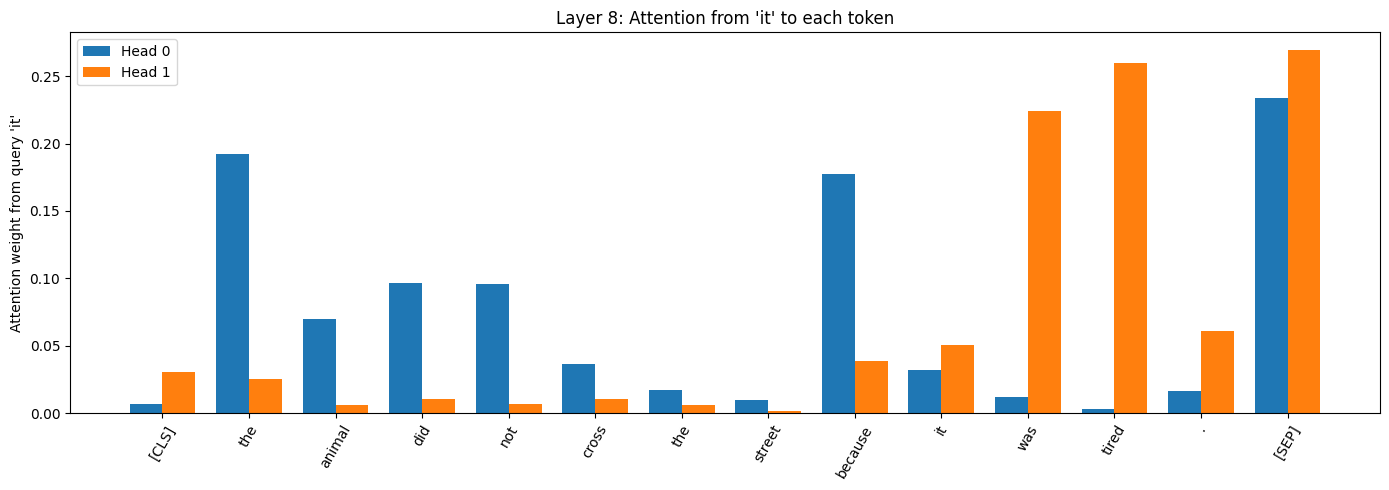

Head 0: 'it'이 가장 크게 참고한 일반 토큰 = 'the' (index=1, weight=0.1923)
Head 1: 'it'이 가장 크게 참고한 일반 토큰 = 'tired' (index=11, weight=0.2598)
Head 0과 Head 1의 'it' attention 분포 평균 절대 차이: 0.084319


In [ ]:
# A안: BERT Multi-Head Attention 비교
from transformers import AutoModel

# attention weight를 반환하도록 eager 구현을 사용합니다.
bert_attn_model = AutoModel.from_pretrained(
    bert_name,
    attn_implementation="eager",
).to(DEVICE)
_ = bert_attn_model.eval()

attn_sentence = "The animal did not cross the street because it was tired."
attn_inputs = bert_tokenizer(attn_sentence, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    attn_outputs = bert_attn_model(**attn_inputs, output_attentions=True)

# attentions: tuple(num_layers), 각 원소 shape = [batch, num_heads, seq_len, seq_len]
attentions = attn_outputs.attentions
assert attentions is not None, "Attention이 반환되지 않았습니다. attn_implementation='eager' 설정을 확인하세요."

tokens = bert_tokenizer.convert_ids_to_tokens(attn_inputs["input_ids"][0])

# TODO 1: 8번째 Encoder layer(0-based index 7)를 선택
layer_idx = 7
layer_attn = attentions[layer_idx][0].detach().cpu()

# TODO 2: Query 토큰 'it'의 위치 찾기.
it_idx = tokens.index("it")

# TODO 3: Head 0과 Head 1에서 Query='it'이 모든 Key 토큰에 주는 Attention 가져오기
head0_it = layer_attn[0, it_idx]
head1_it = layer_attn[1, it_idx]

print("tokens:", tokens)
print("layer attention shape:", layer_attn.shape)
print("query token:", tokens[it_idx], "(index", it_idx, ")")

# 특수 토큰까지 포함한 전체 분포를 막대그래프로 비교
x = np.arange(len(tokens))
width = 0.38
plt.figure(figsize=(14, 5))
plt.bar(x - width/2, head0_it.numpy(), width, label="Head 0")
plt.bar(x + width/2, head1_it.numpy(), width, label="Head 1")
plt.xticks(x, tokens, rotation=60)
plt.ylabel("Attention weight from query 'it'")
plt.title(f"Layer {layer_idx+1}: Attention from 'it' to each token")
plt.legend()
plt.tight_layout()
plt.show()

# 각 Head에서 'it'이 가장 많이 참고한 일반 토큰 확인
# [CLS], [SEP]는 해석을 위해 제외합니다.
special_ids = {0, len(tokens)-1}
valid_indices = [i for i in range(len(tokens)) if i not in special_ids]

def top_key_for_head(weights, valid_indices):
    best = max(valid_indices, key=lambda i: float(weights[i]))
    return best, tokens[best], float(weights[best])

for h, w in [(0, head0_it), (1, head1_it)]:
    idx, tok, val = top_key_for_head(w, valid_indices)
    print(f"Head {h}: 'it'이 가장 크게 참고한 일반 토큰 = {tok!r} (index={idx}, weight={val:.4f})")

mean_abs_diff = torch.mean(torch.abs(head0_it - head1_it)).item()
print(f"Head 0과 Head 1의 'it' attention 분포 평균 절대 차이: {mean_abs_diff:.6f}")


### A안 결과 해석

- **선택:** A
- **변경한 조건:** Head 0, Head 1로 바꿔가며 Attention 분포를 비교했다.
- **관찰 결과:** Head 0에서는 it이 일반 토큰 중 the에 가장 큰 Attention을 주었고, Head 1 에서는 tired에 가장 큰 attention을 주었다. Head 0과 Head 1의 it attention 분포의 평균 절대 차이는 0.084319로 같은 Query 토큰이라도 Head에 따라 서로 다른 토큰에 주목한다는 것을 확인할 수 있었다.
- **해석:** Multi-Head Attention은 Head마다 서로 다른 Q/K/V projection 행렬을 학습하기 때문에 동일한 입력이라도 각 Head가 서로 다른 부분공간으로 투영되기 때문에 attention 분포가 다르다.

---

## B안. GPT Temperature에 따른 생성 다양성 비교

같은 Prompt에서 **temperature만 변경**했을 때 생성 결과의 다양성과 자연스러움이 어떻게 달라지는지 비교합니다.

- Prompt는 모든 실험에서 동일하게 유지합니다.
- `temperature = 0.3, 0.8, 1.5`를 비교합니다.
- 각 temperature에서 **3회 생성**합니다.
- `top_k=50`, 생성 길이 등 나머지 조건은 동일하게 유지합니다.
- 생성 결과의 **다양성(Diversity)** 과 **문맥의 자연스러움(Coherence)** 을 비교합니다.

### 확인할 질문
1. 어느 temperature에서 3개의 생성 결과가 가장 비슷했고, 어느 temperature에서 가장 다양했나요? 실제 생성 문장의 일부를 근거로 설명해세요.
2. temperature가 높아질수록 문장의 자연스러움과 다양성이 어떻게 변했나요? 예상과 다른 결과가 나왔다면 그 결과도 그대로 편하게 적어주세요.
3. temperature가 Softmax 확률분포에 미치는 영향을 위 실험 결과와 연결해 설명하세요.


In [ ]:
# B안: temperature에 따른 GPT 생성 다양성 비교
# 여러 방향으로 자연스럽게 이어질 수 있는 prompt를 사용합니다.
prompt = "Once upon a time, a robot discovered"

# TODO 1: 비교할 temperature 값을 입력
temps = [____, ____, ____]

# top_k, 생성 길이 등은 모든 조건에서 동일하게 고정하고
# temperature만 변경하여 그 효과를 비교합니다.
for temp in temps:
    print(f"\n===== temperature={temp} =====")

    # 같은 temperature에서도 3번 생성하여 결과의 다양성을 확인합니다.
    for trial in range(3):
        # 각 temperature에서 같은 trial끼리는 동일한 seed를 사용합니다.
        torch.manual_seed(SEED + trial)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + trial)

        temp_inputs = gpt_tokenizer(
            prompt,
            return_tensors="pt"
        ).to(DEVICE)

        generated = gpt_model.generate(
            **temp_inputs,
            # TODO 2: 새롭게 생성할 토큰 수를 40으로 설정
            max_new_tokens=____,
            # TODO 3: sampling을 사용하도록 설정
            do_sample=____,
            # TODO 4: 현재 반복문의 temperature를 적용
            temperature=____,
            # 모든 조건에서 동일하게 유지합니다.
            top_k=50,
            pad_token_id=gpt_tokenizer.eos_token_id,
        )

        text = gpt_tokenizer.decode(
            generated[0],
            skip_special_tokens=True
        )

        print(f"\n[생성 {trial + 1}]")
        print(text)


### B안 결과 해석

- **선택:** B
- **변경한 조건:** 어떤 조건을 고정하고 무엇만 변경했는지 작성하세요.
- **관찰 결과:** temperature별 3개의 실제 생성 결과를 비교하고, 구체적인 문장 일부를 인용하세요.
- **해석:** `temperature → Softmax 확률분포 → 다양성/자연스러움`의 관계를 설명하세요.
- **주의:** Sampling 결과는 확률적이므로 이론적인 경향과 완벽하게 일치하지 않을 수 있습니다. 예상과 다른 결과가 나오더라도 실제 출력값을 근거로 타당하게 해석하세요.


# 3. 전체 결과 정리 및 회고

아래 표를 **본인의 실제 실행 결과**를 바탕으로 채워주세요.

| 단계 | 본인이 관찰한 핵심 결과 | 연결되는 개념 |
|---|---|---|
| Attention 직접 구현 | Query[0]이 Key[0]에 가장 큰 가중치(0.4555)를 주었고, Output은 특정 Value 하나가 아니라 세 Value의 가중합([6.1546, 3.8454])으로 나왔다. | Scaled Dot-Product Attention |
| Causal Mask 적용 | Mask 적용 후 Query 0의 Weight가 [1.0, 0.0, 0.0]이 되어 자기 자신만 참고했고, 전체 Weight 행렬이 삼각형 모양이 되었다. | Look-ahead Mask, Masked Self-Attention |
| BERT 실험 | I went to the [MASK] to withdraw money. 문장에서 top-5 예측이 ['bank', 'banks', 'store', 'atm', 'office']로, [MASK] 뒤 문맥까지 활용해 'bank'를 가장 높은 확률로 예측했다. | Encoder 기반, 양방향 문맥, Masked Language Model |
| GPT 실험 | I went to the bank to withdraw 다음 토큰 top-5가 [' money', ' my', ' the', ' $', ' some']이었고, greedy 생성 결과 20개 토큰이 이어졌다. | Decoder 기반, Causal Mask, 이전 토큰만 이용하는 Autoregressive Language Model |

1. **가장 어려웠던 단계와 해결 방법**
   - 답: autoagressive 부분 개념이 헷갈린는 부분이 많았던것 같다. AI도 활용하고 구글 검색을 통해 해결했다.
2. **실행 전 예상과 실제 결과가 가장 달랐던 부분**
   - 답: GPT가 money 다음으로 some을 예측할 줄 알았는데 money 다음으로 my, the, $, some 순으로 나왔다.
3. **기술블로그의 ‘과제 복습’ 섹션에 정리할 핵심 개념**
   - 답: BERT 와 GPT의 차이점


# 4. 생성형 AI 활용 방법 및 대화 내역

> **반드시 작성하세요.** 문제를 풀면서 GPT, Claude 등 생성형 AI를 어디에 어떻게 사용했는지 기록합니다.

## 1) 활용한 생성형 AI
- 사용한 도구: Claude
- 사용한 문제/단계: 1-2 4번 Padding Mask와 Look-ahead Mask, 1-3 4번 autoregressive
- 사용 목적: 개념 확인

## 2) AI 답변을 그대로 사용하지 않고 직접 검증한 방법
- 답: 구글 검색을 통해 한번 더 확인

## 3) AI와의 실제 대화 내역
### 대화 내역
트랜스포머(Transformer)에서 어텐션 계산 시 특정 위치를 "보지 못하게" 막는 두 가지 마스킹 기법입니다.

**패딩 마스크(padding mask)**는 배치 내 문장 길이를 맞추기 위해 넣은 패딩 토큰(보통 `<pad>`)을 어텐션 계산에서 무시하도록 만드는 장치입니다. 문장들은 길이가 제각각인데 행렬 연산을 하려면 같은 길이로 맞춰야 하니, 짧은 문장 뒤에 의미 없는 패딩 토큰을 채워 넣습니다. 문제는 이 패딩 토큰이 실제 의미가 없는데도 어텐션 스코어 계산에 끼어들면 결과가 왜곡된다는 점입니다. 그래서 패딩 위치에 해당하는 어텐션 스코어를 매우 작은 값(예: -infinity 혹은 -1e9)으로 만들어서, 소프트맥스를 거치면 그 위치의 가중치가 사실상 0이 되게 합니다. 인코더와 디코더 양쪽 모두, 입력에 패딩이 있는 한 적용됩니다.

**룩어헤드 마스크(look-ahead mask, causal mask라고도 함)**는 디코더의 셀프 어텐션에서 사용되며, 특정 시점의 토큰이 자기보다 미래에 오는 토큰을 미리 참조하지 못하게 막습니다. 트랜스포머는 RNN과 달리 모든 토큰을 한 번에 병렬로 처리하기 때문에, 아무 조치가 없으면 디코더가 학습 중에 정답 시퀀스의 미래 토큰까지 다 보고 다음 단어를 예측하는 "치팅"이 가능해집니다. 이를 막기 위해 대각선 아래쪽(현재와 과거)만 허용하고 대각선 위쪽(미래)은 -infinity로 마스킹하는 상삼각행렬 형태의 마스크를 어텐션 스코어에 더해줍니다. 그 결과 i번째 위치는 0~i번째 토큰만 보고 예측하게 되어, 실제 추론(inference) 시 한 토큰씩 순차 생성하는 방식과 일관성을 유지합니다.

정리하면, 패딩 마스크는 "의미 없는 패딩을 무시"하기 위한 것이고, 룩어헤드 마스크는 "미래 정보를 못 보게" 하기 위한 것입니다. 디코더의 셀프 어텐션에서는 이 둘을 합쳐서(두 마스크를 더하거나 OR 연산) 함께 사용하는 경우가 많습니다.



오토리그레시브(autoregressive)는 "이전에 생성된 출력을 다시 입력으로 사용해서 다음 출력을 예측하는" 방식을 말합니다. 통계학에서 유래한 개념(자기 자신의 과거 값으로 현재 값을 예측하는 회귀모델)인데, 딥러닝/NLP에서는 시퀀스를 한 번에 통째로 생성하지 않고 토큰을 하나씩 순차적으로 생성하는 모델 구조를 가리키는 말로 주로 씁니다.

작동 방식은 이렇습니다. 문장을 생성할 때 t번째 토큰을 예측하려면 0번째부터 t-1번째까지 이미 생성된 토큰들만 입력으로 사용하고, t번째 토큰이 나오면 그것을 다시 입력에 추가해서 t+1번째 토큰을 예측합니다. 즉 확률적으로는 전체 시퀀스의 확률을 다음과 같이 조건부 확률의 곱으로 분해하는 것과 같습니다.

P(x1, x2, ..., xn) = P(x1) × P(x2|x1) × P(x3|x1,x2) × ... × P(xn|x1,...,x(n-1))

GPT 계열 언어모델이 대표적인 오토리그레시브 모델입니다. "오늘 날씨가"까지 생성했으면 그다음에 "좋다" 같은 단어를 그 문맥을 보고 예측하고, 그 단어를 다시 입력에 붙여서 그다음 단어를 예측하는 식으로 문장을 끝까지 만들어갑니다.

이게 바로 앞서 얘기한 룩어헤드 마스크와 직결됩니다. 학습 단계에서는 정답 문장 전체를 한 번에 모델에 넣고 병렬로 계산하지만, 오토리그레시브 특성을 지키려면 t번째 위치가 미래(t+1번째 이후) 토큰을 못 보게 막아야 합니다. 그래서 룩어헤드 마스크로 미래를 가려서, 학습 때도 실제 추론 때처럼 "과거만 보고 다음을 예측"하는 상황을 인위적으로 재현하는 것입니다.

반대 개념으로는 non-autoregressive(비자기회귀) 모델이 있는데, 이건 모든 출력 토큰을 동시에(병렬로) 한 번에 생성합니다. 속도는 훨씬 빠르지만, 토큰 간 의존성을 반영하기 어려워서 품질이 떨어지는 경우가 많아 아직은 오토리그레시브 방식이 언어 생성의 주류입니다.